In [1]:
pip install networkx matplotlib


Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd

df = pd.read_csv("../enriched_ecommerce_data.csv")

df.head(500)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delivery_delay_days,...,product_height_cm,product_width_cm,product_length_norm,product_height_norm,product_width_norm,payment_sequential,payment_type,payment_installments,payment_value,payment_value_norm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,8.0,13.0,0.122449,0.058252,0.062500,1.0,credit_card,1.0,18.12,0.001325
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,8.0,13.0,0.122449,0.058252,0.062500,3.0,voucher,1.0,2.00,0.000146
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,8.0,13.0,0.122449,0.058252,0.062500,2.0,voucher,1.0,18.59,0.001360
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,...,13.0,19.0,0.122449,0.106796,0.116071,1.0,boleto,1.0,141.46,0.010352
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,...,19.0,21.0,0.173469,0.165049,0.133929,1.0,credit_card,3.0,179.12,0.013108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,e659b8223be6f632acb24fb80cf50ca9,9ac71dee8847ffe35fb2c087da733cc4,delivered,2017-11-18 11:30:58,2017-11-18 11:47:19,2017-11-20 14:59:10,2017-12-08 17:29:17,2017-12-18,20,-10,...,2.0,17.0,0.173469,0.000000,0.098214,1.0,credit_card,4.0,87.21,0.006382
496,b693d6c35867fa1937455e04f2547df2,eec909ab0da04f0d3e92f898c6994d37,delivered,2017-05-11 09:13:17,2017-05-11 09:25:21,2017-05-11 10:09:25,2017-05-16 09:42:08,2017-05-31,5,-15,...,10.0,12.0,0.102041,0.077670,0.053571,1.0,credit_card,5.0,109.31,0.007999
497,0f9dc92df0635605588c51ec2e4c58a0,4f31c34bf33334525417bab91b4794da,delivered,2017-12-27 19:19:44,2017-12-27 19:29:30,2018-01-03 20:10:20,2018-01-10 18:10:04,2018-01-26,13,-16,...,7.0,55.0,0.459184,0.048544,0.437500,1.0,credit_card,4.0,133.35,0.009758
498,8efc076145638bcd5298053ddde6ff0c,faa299ecd22a2998858efc7cb87011bc,delivered,2018-01-09 11:19:49,2018-01-09 11:29:43,2018-01-10 18:19:02,2018-01-11 13:51:51,2018-01-23,2,-12,...,2.0,11.0,0.091837,0.000000,0.044643,1.0,credit_card,1.0,49.41,0.003615


In [7]:
G = nx.Graph()

for _, row in df.head(50).iterrows():
    customer = row['customer_id']
    order = row['order_id']
    product = row['product_id']
    payment = row['payment_type']

    G.add_node(customer, type="customer")
    G.add_node(order, type="order")
    G.add_node(product, type="product")
    G.add_node(payment, type="payment")

    G.add_edge(customer, order, relation="PLACED")
    G.add_edge(order, product, relation="CONTAINS")
    G.add_edge(order, payment, relation="PAID_WITH")

In [3]:
for _, row in df.head(500).iterrows():
    customer = row['customer_id']
    order = row['order_id']
    product = row['product_id']

    G.add_node(customer, type="customer")
    G.add_node(order, type="order")
    G.add_node(product, type="product")

    G.add_edge(customer, order, relation="PLACED")
    G.add_edge(order, product, relation="CONTAINS")

print("Graph created successfully!")

Graph created successfully!


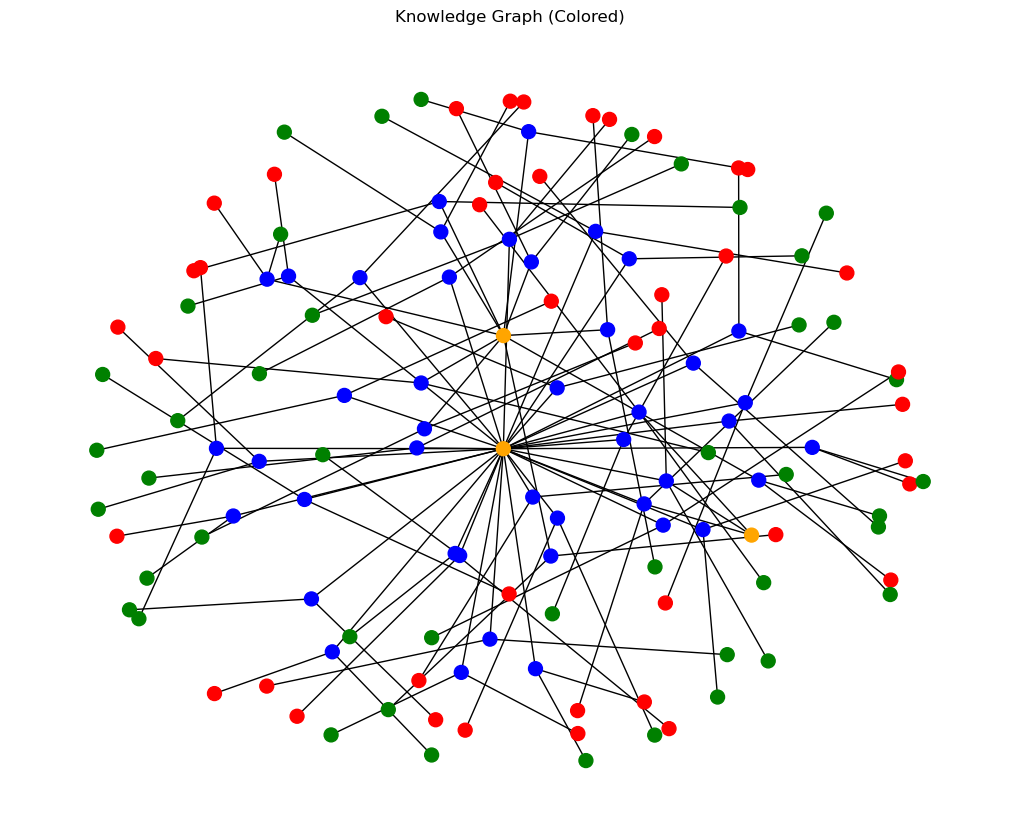

In [9]:
color_map = []

for node in G.nodes(data=True):
    if node[1]['type'] == 'customer':
        color_map.append('red')
    elif node[1]['type'] == 'order':
        color_map.append('blue')
    elif node[1]['type'] == 'product':
        color_map.append('green')
    else:
        color_map.append('orange')

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, k=0.5)

nx.draw(G, pos, node_color=color_map, node_size=100)

plt.title("Knowledge Graph (Colored)")
plt.show()